Shape total de X: (7390, 224, 224, 3)
Shape total de y: (7390,)
Total PERROS: 4990
Total GATOS: 2400
Class weights: {0: np.float64(0.7404809619238477), 1: np.float64(1.5395833333333333)}


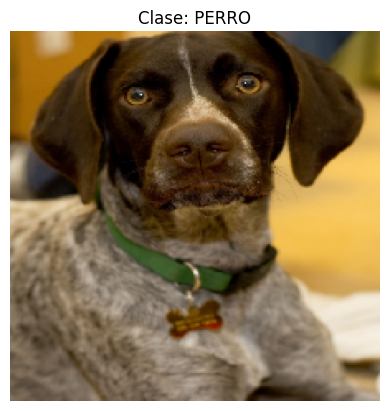

Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.5780 - loss: 0.6984 - val_accuracy: 0.6928 - val_loss: 0.5879
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.6470 - loss: 0.6268 - val_accuracy: 0.6908 - val_loss: 0.5660
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.6605 - loss: 0.6117 - val_accuracy: 0.6982 - val_loss: 0.5585
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.6849 - loss: 0.5891 - val_accuracy: 0.7551 - val_loss: 0.5047
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - accuracy: 0.6920 - loss: 0.5797 - val_accuracy: 0.7219 - val_loss: 0.5511
Epoch 6/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.7026 - loss: 0.5732 - val_accuracy: 0.7341 - val_loss: 0.5205
Epoch 7/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 140s 753ms/step - accuracy: 0.7096 - loss: 0.5547 - val_accuracy: 0.7578 - val_loss: 0.4977
Epoch 8/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 128s 691ms/step - accuracy: 0.7272 - loss: 0.5446 - va

In [4]:
########################################################################
############ CLASIFICACIÓN BINARIA GATOS VS PERROS USANDO CNN ##########
########################################################################

import os
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# PASO 0. RUTAS DE LAS CLASES
# ============================================================
ruta_perros = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\OXFORD\PERROS"
ruta_gatos = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\OXFORD\GATOS"

IMG_HEIGHT = 224
IMG_WIDTH = 224

classes = [
    ("PERRO", ruta_perros),
    ("GATO", ruta_gatos)
]

# ============================================================
# PASO 1. CARGA DE IMÁGENES
# ============================================================
X = []
y = []

for class_index, (class_name, class_folder) in enumerate(classes):

    for root, _, files in os.walk(class_folder):
        for file_name in files:
            if not file_name.lower().endswith((".png", ".jpg", ".jpeg")):
                continue

            file_path = os.path.join(root, file_name)

            try:
                img = tf.keras.utils.load_img(
                    file_path,
                    color_mode="rgb",
                    target_size=(IMG_HEIGHT, IMG_WIDTH)
                )

                img_array = tf.keras.utils.img_to_array(img)

                X.append(img_array)
                y.append(class_index)

            except Exception as e:
                print(f"Error al leer {file_path}: {e}")

X = np.array(X)
y = np.array(y)

print("Shape total de X:", X.shape)
print("Shape total de y:", y.shape)
print("Total PERROS:", np.sum(y == 0))
print("Total GATOS:", np.sum(y == 1))

# ============================================================
# PASO 2. PREPROCESAMIENTO
# ============================================================
X = X.astype("float32")
X /= 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ============================================================
# 🔥 PASO NUEVO: CLASS WEIGHT
# ============================================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],  # PERRO
    1: class_weights[1]   # GATO
}

print("Class weights:", class_weight_dict)

# ============================================================
# PASO 3. VISUALIZAR
# ============================================================
plt.imshow(X_train[0])
plt.title(f"Clase: {classes[y_train[0]][0]}")
plt.axis("off")
plt.show()

# ============================================================
# PASO 4. DATA AUGMENTATION
# ============================================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# ============================================================
# PASO 5. MODELO
# ============================================================
model = Sequential()

# Capa de entrada
model.add(tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Data augmentation
model.add(data_augmentation)

# Bloque 1
model.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
model.add(MaxPool2D((2, 2)))

# Bloque 2
model.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model.add(MaxPool2D((2, 2)))

# Bloque 3
model.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model.add(MaxPool2D((2, 2)))

# Regularización
model.add(Dropout(0.30))

# Aplanado
model.add(Flatten())

# Capa densa
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.50))

# Salida binaria
model.add(Dense(1, activation="sigmoid"))

# ============================================================
# PASO 6. COMPILACIÓN
# ============================================================
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# ============================================================
# PASO 7. EARLY STOPPING
# ============================================================
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

# ============================================================
# PASO 8. ENTRENAMIENTO (CON CLASS_WEIGHT 🔥)
# ============================================================
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

# ============================================================
# PASO 9. EVALUACIÓN
# ============================================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

acc = accuracy_score(y_test, y_pred)
print("Accuracy score (sklearn):", acc)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["PERRO", "GATO"]))


# ============================================================
# PASO 10. GUARDAR MODELO 🔥
# ============================================================
ruta_guardado = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\modelo_fase1_perro_gato.keras"

model.save(ruta_guardado)

print("\nModelo guardado en:", ruta_guardado)

1.jpg → PERRO (0.8964)


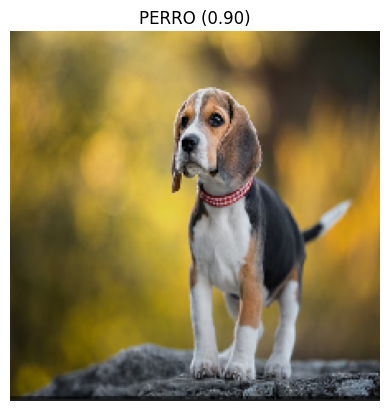

2.jpg → PERRO (0.6462)


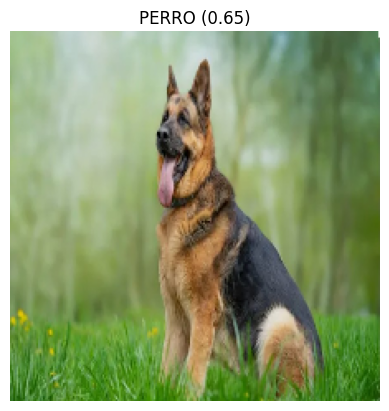

3.jpg → GATO (0.9997)


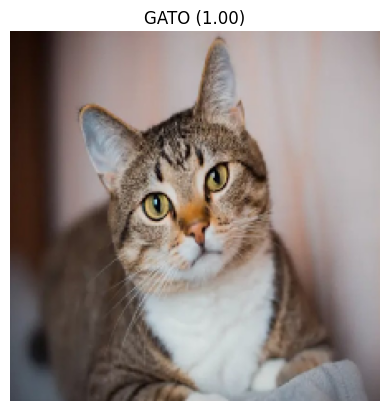

4.jpg → GATO (0.5529)


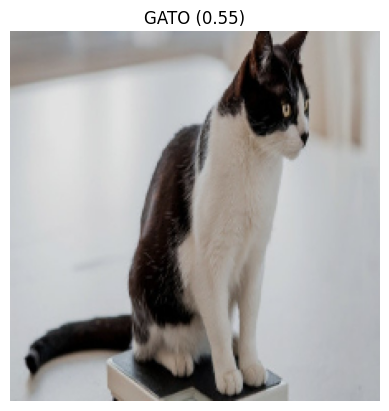

5.jpg → PERRO (0.9749)


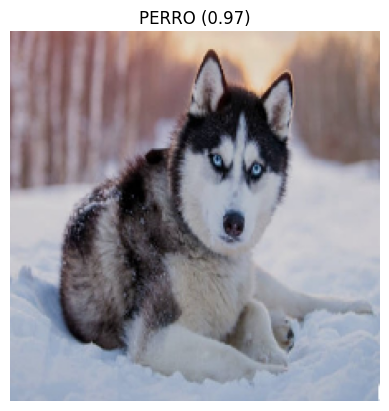

In [6]:
########################################################################
######### PRUEBA DE CARPETA COMPLETA - PERRO VS GATO ###################
########################################################################

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import load_model

# ============================================================
# RUTAS
# ============================================================
ruta_modelo = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\modelo_fase1_perro_gato.keras"

ruta_carpeta = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\OXFORD\IMAGENES PRUEBA"

# ============================================================
# PARÁMETROS
# ============================================================
IMG_HEIGHT = 224
IMG_WIDTH = 224

# ============================================================
# CARGAR MODELO
# ============================================================
model = load_model(ruta_modelo)

# ============================================================
# RECORRER CARPETA
# ============================================================
for archivo in os.listdir(ruta_carpeta):

    if not archivo.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    ruta_imagen = os.path.join(ruta_carpeta, archivo)

    try:
        # Cargar imagen
        img = tf.keras.utils.load_img(
            ruta_imagen,
            target_size=(IMG_HEIGHT, IMG_WIDTH)
        )

        img_array = tf.keras.utils.img_to_array(img)
        img_array = img_array.astype("float32") / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predicción
        prob = model.predict(img_array, verbose=0)[0][0]

        if prob >= 0.5:
            clase = "GATO"
            confianza = prob
        else:
            clase = "PERRO"
            confianza = 1 - prob

        # Mostrar resultado en consola
        print(f"{archivo} → {clase} ({confianza:.4f})")

        # Mostrar imagen
        plt.imshow(img)
        plt.title(f"{clase} ({confianza:.2f})")
        plt.axis("off")
        plt.show()

    except Exception as e:
        print(f"Error con {archivo}: {e}")

Found 4990 files belonging to 25 classes.
Using 3992 files for training.
Found 4990 files belonging to 25 classes.
Using 998 files for validation.
Razas de perro: ['American bulldog', 'American pitbull', 'Basset hound', 'Beagle', 'Boxer', 'Chihuahua', 'English cocker', 'English setter', 'German', 'Great pyrenees', 'Havanese', 'Japanese chin', 'Keeshond', 'Leonberger', 'Miniature pinscher', 'Newfoundland', 'Pomeranian', 'Pug', 'Saint bernard', 'Samoyed', 'Scottish', 'Shiba', 'Staffordshire', 'Wheaten', 'Yorkshire']
Número de clases: 25


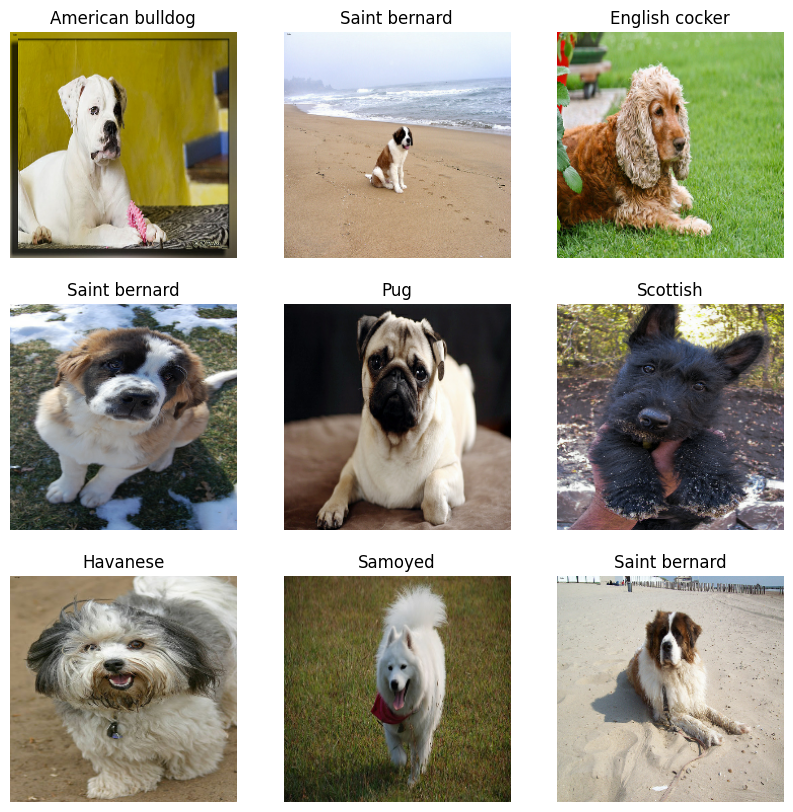

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 84s 640ms/step - accuracy: 0.6556 - loss: 1.2196 - val_accuracy: 0.9098 - val_loss: 0.3286
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 629ms/step - accuracy: 0.8402 - loss: 0.5221 - val_accuracy: 0.9259 - val_loss: 0.2622
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 630ms/step - accuracy: 0.8662 - loss: 0.4280 - val_accuracy: 0.9299 - val_loss: 0.2496
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 629ms/step - accuracy: 0.8808 - loss: 0.3724 - val_accuracy: 0.9259 - val_loss: 0.2554
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 72s 577ms/step - accuracy: 0.9023 - loss: 0.3160 - val_accuracy: 0.9299 - val_loss: 0.2321
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 569ms/step - accuracy: 0.8968 - loss: 0.3103 - val_accuracy: 0.9279 - val_loss: 0.2457
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 71s 571ms/step - accuracy: 0.8975 - loss: 0.3002 - val_accuracy: 0.9339 - val_loss: 0.2375
Epoch 8/20
125/125 ━━━━━━━━━━━━━━

In [7]:
########################################################################
########## CLASIFICACIÓN DE RAZAS DE PERROS - TRANSFER LEARNING ########
########################################################################

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# PASO 0. RUTA DEL DATASET
# ============================================================
ruta_perros = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\OXFORD\PERROS"

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

# ============================================================
# PASO 1. CARGA DEL DATASET
# ============================================================
train_dataset = tf.keras.utils.image_dataset_from_directory(
    ruta_perros,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    ruta_perros,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)

print("Razas de perro:", class_names)
print("Número de clases:", num_classes)

# ============================================================
# PASO 2. OPTIMIZAR DATASET
# ============================================================
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

# ============================================================
# PASO 3. VISUALIZAR EJEMPLOS
# ============================================================
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# ============================================================
# PASO 4. DATA AUGMENTATION
# ============================================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# ============================================================
# PASO 5. MODELO BASE PREENTRENADO
# ============================================================
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

# ============================================================
# PASO 6. MODELO FINAL
# ============================================================
model = Sequential([
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    data_augmentation,
    tf.keras.layers.Lambda(preprocess_input),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.30),
    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(num_classes, activation="softmax")
])

# ============================================================
# PASO 7. COMPILACIÓN
# ============================================================
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# PASO 8. EARLY STOPPING
# ============================================================
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

# ============================================================
# PASO 9. ENTRENAMIENTO
# ============================================================
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

# ============================================================
# PASO 10. EVALUACIÓN
# ============================================================
test_loss, test_acc = model.evaluate(val_dataset, verbose=0)
print("Validation loss:", test_loss)
print("Validation accuracy:", test_acc)

# ============================================================
# PASO 11. MATRIZ DE CONFUSIÓN Y REPORTE
# ============================================================
y_true = []
y_pred = []

for images, labels in val_dataset:
    predicciones = model.predict(images, verbose=0)
    clases_predichas = np.argmax(predicciones, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(clases_predichas)

print("\nMatriz de confusión:")
print(confusion_matrix(y_true, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ============================================================
# PASO 12. GUARDAR MODELO
# ============================================================
ruta_guardado = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\modelo_razas_perros.keras"

model.save(ruta_guardado)

print("\nModelo guardado en:", ruta_guardado)

Found 2400 files belonging to 12 classes.
Using 1920 files for training.
Found 2400 files belonging to 12 classes.
Using 480 files for validation.
Razas de gatos: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair', 'Egyptian', 'Maine', 'Persian', 'Ragdoll', 'Russian Blue', 'Siamese', 'Sphynx']
Número de clases: 12


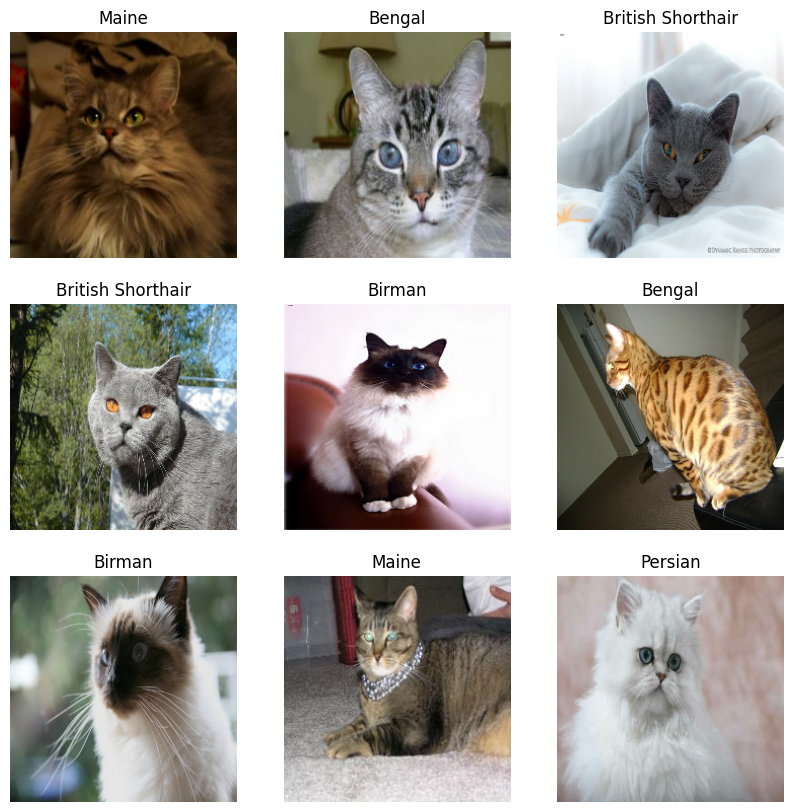

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 42s 639ms/step - accuracy: 0.4917 - loss: 1.5005 - val_accuracy: 0.8021 - val_loss: 0.6008
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 38s 634ms/step - accuracy: 0.7526 - loss: 0.7174 - val_accuracy: 0.8313 - val_loss: 0.5013
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 38s 630ms/step - accuracy: 0.8115 - loss: 0.5540 - val_accuracy: 0.8354 - val_loss: 0.4654
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 39s 648ms/step - accuracy: 0.8260 - loss: 0.5032 - val_accuracy: 0.8458 - val_loss: 0.3905
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 677ms/step - accuracy: 0.8385 - loss: 0.4569 - val_accuracy: 0.8458 - val_loss: 0.3925
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 42s 693ms/step - accuracy: 0.8401 - loss: 0.4385 - val_accuracy: 0.8562 - val_loss: 0.4082
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 39s 643ms/step - accuracy: 0.8557 - loss: 0.4089 - val_accuracy: 0.8750 - val_loss: 0.3494
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 670ms/step - accuracy: 0.8604 - loss: 0.3828 - val_accu

In [8]:
########################################################################
########## CLASIFICACIÓN DE RAZAS DE PERROS - TRANSFER LEARNING ########
########################################################################

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# PASO 0. RUTA DEL DATASET
# ============================================================
ruta_perros = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\OXFORD\GATOS"

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

# ============================================================
# PASO 1. CARGA DEL DATASET
# ============================================================
train_dataset = tf.keras.utils.image_dataset_from_directory(
    ruta_perros,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    ruta_perros,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)

print("Razas de gatos:", class_names)
print("Número de clases:", num_classes)

# ============================================================
# PASO 2. OPTIMIZAR DATASET
# ============================================================
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

# ============================================================
# PASO 3. VISUALIZAR EJEMPLOS
# ============================================================
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# ============================================================
# PASO 4. DATA AUGMENTATION
# ============================================================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# ============================================================
# PASO 5. MODELO BASE PREENTRENADO
# ============================================================
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

# ============================================================
# PASO 6. MODELO FINAL
# ============================================================
model = Sequential([
    tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    data_augmentation,
    tf.keras.layers.Lambda(preprocess_input),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.30),
    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(num_classes, activation="softmax")
])

# ============================================================
# PASO 7. COMPILACIÓN
# ============================================================
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ============================================================
# PASO 8. EARLY STOPPING
# ============================================================
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

# ============================================================
# PASO 9. ENTRENAMIENTO
# ============================================================
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stopping],
    verbose=1
)

# ============================================================
# PASO 10. EVALUACIÓN
# ============================================================
test_loss, test_acc = model.evaluate(val_dataset, verbose=0)
print("Validation loss:", test_loss)
print("Validation accuracy:", test_acc)

# ============================================================
# PASO 11. MATRIZ DE CONFUSIÓN Y REPORTE
# ============================================================
y_true = []
y_pred = []

for images, labels in val_dataset:
    predicciones = model.predict(images, verbose=0)
    clases_predichas = np.argmax(predicciones, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(clases_predichas)

print("\nMatriz de confusión:")
print(confusion_matrix(y_true, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ============================================================
# PASO 12. GUARDAR MODELO
# ============================================================
ruta_guardado = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\modelo_razas_gatos.keras"

model.save(ruta_guardado)

print("\nModelo guardado en:", ruta_guardado)